# Vanguard Digital Experiment - Phase 2: Performance Metrics (KPIs)

## Business Context

Vanguard ran an A/B test (3/15/2017 - 6/20/2017) to test whether a redesigned
digital interface improves the online process. Clients move through the funnel:

`start -> step_1 -> step_2 -> step_3 -> confirm`

- **Control:** traditional interface
- **Test:** redesigned interface

## Objective of this notebook

Define and compute the KPIs that determine the success of the redesign, and
compare the **Test** group against the **Control** group:

1. **Completion rate** - share of journeys reaching `confirm`
2. **Time spent on each step** - average duration per step
3. **Error rate** - backward movements in the funnel
4. **Additional KPIs** - funnel drop-off, bounce rate, step repeats, time-to-complete
5. **Redesign verdict** - consolidated comparison

## Unit of analysis

The primary unit is the **visit (`visit_id`) = one session / one attempt at the
funnel**. This is the standard A/B unit: each session is an independent attempt.
A client with several sessions contributes several journeys. Completion rate is
also reported at the **client level** as a cross-check.

> This notebook is **self-contained**: it reloads and re-cleans the raw files
> using the same logic as Phase 1, so it runs standalone.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid")

import warnings
warnings.filterwarnings("ignore")

# Consistent group colors
GROUP_COLORS = {"Control": "#4C78A8", "Test": "#F58518"}

## 1. Load and rebuild the cleaned, experiment-ready dataset

Same cleaning logic as Phase 1:
- concatenate the two web files and drop exact duplicate events
- parse `date_time` to datetime
- standardize unknown gender values and drop rows with missing demographics
- drop clients with no experiment assignment
- inner-join web events with the experiment roster (keeps only Test/Control),
  then left-join demographics

In [2]:
# --- Load raw datasets ---
df_demo  = pd.read_csv("df_final_demo.txt")
df_exp   = pd.read_csv("df_final_experiment_clients.txt")
df_web_1 = pd.read_csv("df_final_web_data_pt_1.txt")
df_web_2 = pd.read_csv("df_final_web_data_pt_2.txt")

# --- Combine + clean web events ---
df_web = pd.concat([df_web_1, df_web_2], axis=0, ignore_index=True)
df_web = df_web.drop_duplicates().copy()
df_web["date_time"] = pd.to_datetime(df_web["date_time"])

# --- Clean demographics ---
df_demo_clean = df_demo.copy()
df_demo_clean["gendr"] = df_demo_clean["gendr"].replace({"U": "Unknown", "X": "Unknown"})
df_demo_clean = df_demo_clean.dropna().copy()

# --- Clean experiment roster ---
df_exp_clean = df_exp.dropna(subset=["Variation"]).copy()

# --- Merge ---
df = df_web.merge(df_exp_clean, on="client_id", how="inner")
df = df.merge(df_demo_clean, on="client_id", how="left")

print("Analytical dataset shape:", df.shape)
print("\nEvents per group:")
print(df["Variation"].value_counts())
df.head()

Analytical dataset shape: (317235, 14)

Events per group:
Variation
Test       176699
Control    140536
Name: count, dtype: int64


,client_id,visitor_id,visit_id,process_step,date_time,Variation,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07,Test,5.0000,64.0000,79.0000,Unknown,2.0000,"189,023.8600",1.0000,4.0000
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51,Test,5.0000,64.0000,79.0000,Unknown,2.0000,"189,023.8600",1.0000,4.0000
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22,Test,5.0000,64.0000,79.0000,Unknown,2.0000,"189,023.8600",1.0000,4.0000
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13,Test,5.0000,64.0000,79.0000,Unknown,2.0000,"189,023.8600",1.0000,4.0000
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04,Test,5.0000,64.0000,79.0000,Unknown,2.0000,"189,023.8600",1.0000,4.0000


### 1.1 Encode the funnel order

We map each step to an ordinal index so we can detect forward vs backward
movement, and sort every visit chronologically.

In [3]:
STEP_ORDER = {"start": 0, "step_1": 1, "step_2": 2, "step_3": 3, "confirm": 4}
STEP_NAMES = ["start", "step_1", "step_2", "step_3", "confirm"]

df["step_index"] = df["process_step"].map(STEP_ORDER)

# Sort events chronologically within each visit (the journey timeline)
df = df.sort_values(["client_id", "visit_id", "date_time"]).reset_index(drop=True)

print("Unique visits:", df["visit_id"].nunique())
print("Unique clients:", df["client_id"].nunique())
df[["client_id", "visit_id", "process_step", "step_index", "date_time", "Variation"]].head(10)

Unique visits: 69205


Unique clients: 50500


,client_id,visit_id,process_step,step_index,date_time,Variation
0,555,637149525_38041617439_716659,start,0,2017-04-15 12:57:56,Test
1,555,637149525_38041617439_716659,step_1,1,2017-04-15 12:58:03,Test
2,555,637149525_38041617439_716659,step_2,2,2017-04-15 12:58:35,Test
3,555,637149525_38041617439_716659,step_3,3,2017-04-15 13:00:14,Test
4,555,637149525_38041617439_716659,confirm,4,2017-04-15 13:00:34,Test
5,647,40369564_40101682850_311847,start,0,2017-04-12 15:41:28,Test
6,647,40369564_40101682850_311847,step_1,1,2017-04-12 15:41:35,Test
7,647,40369564_40101682850_311847,step_2,2,2017-04-12 15:41:53,Test
8,647,40369564_40101682850_311847,step_3,3,2017-04-12 15:45:02,Test
9,647,40369564_40101682850_311847,confirm,4,2017-04-12 15:47:45,Test


### 1.2 Build a per-visit summary table

One row per `visit_id`, capturing the facts every KPI needs: the group, whether
`confirm` was reached, the furthest step, event count, and start/end timestamps.

In [4]:
visit = df.groupby("visit_id").agg(
    Variation       =("Variation", "first"),
    client_id       =("client_id", "first"),
    reached_confirm =("process_step", lambda s: "confirm" in set(s)),
    max_step        =("step_index", "max"),
    n_events        =("process_step", "size"),
    start_time      =("date_time", "min"),
    end_time        =("date_time", "max"),
)
print("Visits summarized:", len(visit))
visit.head()

Visits summarized: 69205


,Variation,client_id,reached_confirm,max_step,n_events,start_time,end_time
visit_id,,,,,,,
100012776_37918976071_457913,Test,3561384,True,4,2,2017-04-26 13:22:17,2017-04-26 13:23:09
100019538_17884295066_43909,Test,7338123,True,4,11,2017-04-09 16:20:56,2017-04-09 16:24:58
100022086_87870757897_149620,Test,2478628,True,4,5,2017-05-23 20:44:01,2017-05-23 20:47:01
100030127_47967100085_936361,Control,105007,False,0,1,2017-03-22 11:07:49,2017-03-22 11:07:49
100037962_47432393712_705583,Control,5623007,False,1,4,2017-04-14 16:41:51,2017-04-14 16:44:03


## 2. Completion Rate

**Definition:** the proportion of journeys that reach the final `confirm` step.
This is the headline KPI - the experiment exists to move this number.

In [5]:
# Visit-level completion
completion = visit.groupby("Variation")["reached_confirm"].agg(
    visits="size", completed="sum"
)
completion["completion_rate"] = completion["completed"] / completion["visits"]
completion

,visits,completed,completion_rate
Variation,,,
Control,32128,15999,0.4980
Test,37077,21681,0.5848


In [6]:
# Client-level cross-check: a client "completes" if ANY of their visits reached confirm
client_completion = (
    visit.groupby(["Variation", "client_id"])["reached_confirm"].max()
    .groupby("Variation").agg(clients="size", completed="sum")
)
client_completion["completion_rate"] = client_completion["completed"] / client_completion["clients"]
client_completion

,clients,completed,completion_rate
Variation,,,
Control,23439,15343,0.6546
Test,26873,18587,0.6917


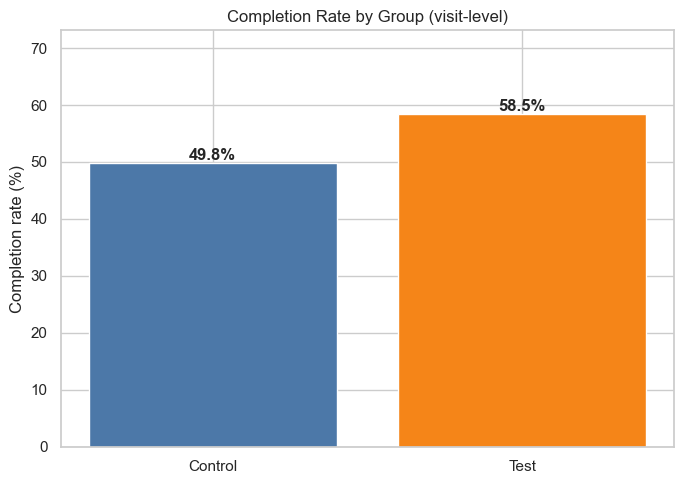

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
rates = (completion["completion_rate"] * 100).reindex(["Control", "Test"])
bars = ax.bar(rates.index, rates.values, color=[GROUP_COLORS[g] for g in rates.index])
ax.set_title("Completion Rate by Group (visit-level)")
ax.set_ylabel("Completion rate (%)")
ax.set_ylim(0, max(rates.values) * 1.25)
for b, v in zip(bars, rates.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Time Spent on Each Step

**Definition:** how long users dwell on a step before their next action.

**Method:** within each visit (sorted by time), the duration of an event is the
gap until the *next* event. That duration is attributed to the step the user was
on. The final event of each visit has no "next" event, so it is dropped
(this also naturally excludes `confirm`, which is terminal).

We report the **median** (robust to users who walk away mid-session and create
huge gaps) alongside the mean.

In [8]:
df_t = df.sort_values(["visit_id", "date_time"]).copy()
df_t["next_time"] = df_t.groupby("visit_id")["date_time"].shift(-1)
df_t["duration_sec"] = (df_t["next_time"] - df_t["date_time"]).dt.total_seconds()

# Keep only events that have a following event (drop the terminal event of each visit)
step_dur = df_t[df_t["duration_sec"].notna() & (df_t["duration_sec"] >= 0)].copy()

time_per_step = (
    step_dur.groupby(["Variation", "process_step"])["duration_sec"]
    .agg(mean_sec="mean", median_sec="median", n="size")
    .reindex(pd.MultiIndex.from_product([["Control", "Test"], STEP_NAMES[:-1]],
                                        names=["Variation", "process_step"]))
)
time_per_step

mean_sec  median_sec      n
Variation process_step                             
Control   start          66.8048     20.0000  35740
          step_1         50.5356     20.0000  26052
          step_2         92.0432     64.0000  24316
          step_3        137.2245     72.0000  20281
Test      start          61.4546     14.0000  46327
          step_1         60.7570     27.0000  35529
          step_2         88.8761     61.0000  29576
          step_3        129.6075     58.0000  23984

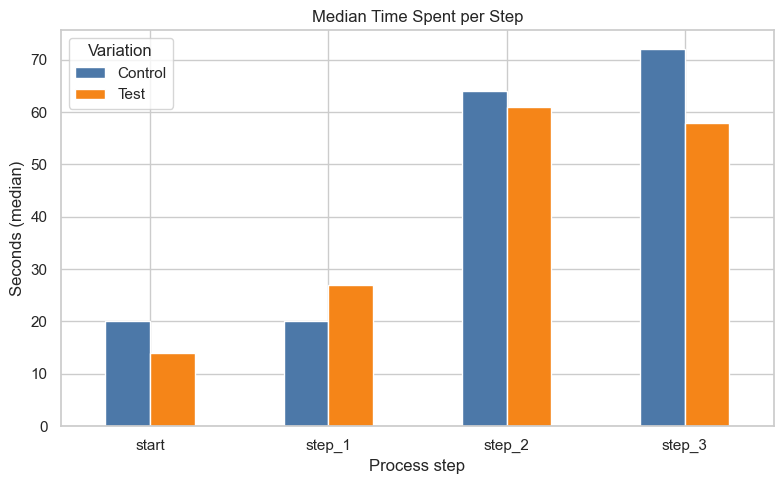

Variation,Control,Test
process_step,,
start,20.0000,14.0000
step_1,20.0000,27.0000
step_2,64.0000,61.0000
step_3,72.0000,58.0000


In [9]:
# Median time per step, side by side
pivot_med = time_per_step["median_sec"].unstack("Variation").reindex(STEP_NAMES[:-1])

ax = pivot_med[["Control", "Test"]].plot(
    kind="bar", figsize=(8, 5), color=[GROUP_COLORS["Control"], GROUP_COLORS["Test"]]
)
ax.set_title("Median Time Spent per Step")
ax.set_ylabel("Seconds (median)")
ax.set_xlabel("Process step")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()
pivot_med

## 4. Error Rate (backward movements)

**Definition:** moving from a later step to an earlier step within the same
visit signals confusion or a mis-step. We flag any event whose step index is
lower than the previous event's index in that visit.

We report two views per group:
- **% of visits with at least one backward move** (did the journey ever stumble?)
- **backward moves per visit** (how often it stumbled)

In [10]:
df_t["prev_step_index"] = df_t.groupby("visit_id")["step_index"].shift(1)
df_t["is_backward"] = df_t["step_index"] < df_t["prev_step_index"]

visit_err = df_t.groupby("visit_id").agg(
    Variation     =("Variation", "first"),
    backward_moves=("is_backward", "sum"),
    total_steps   =("process_step", "size"),
)
visit_err["has_error"] = visit_err["backward_moves"] > 0

error_summary = visit_err.groupby("Variation").agg(
    visits           =("has_error", "size"),
    visits_with_error=("has_error", "sum"),
    total_backward   =("backward_moves", "sum"),
    total_steps      =("total_steps", "sum"),
)
error_summary["pct_visits_with_error"] = error_summary["visits_with_error"] / error_summary["visits"]
error_summary["backward_per_visit"]    = error_summary["total_backward"] / error_summary["visits"]
error_summary["error_rate_per_step"]   = error_summary["total_backward"] / error_summary["total_steps"]
error_summary

,visits,visits_with_error,total_backward,total_steps,pct_visits_with_error,backward_per_visit,error_rate_per_step
Variation,,,,,,,
Control,32120,6576,9685,140422,0.2047,0.3015,0.0690
Test,37085,10043,16355,176813,0.2708,0.4410,0.0925


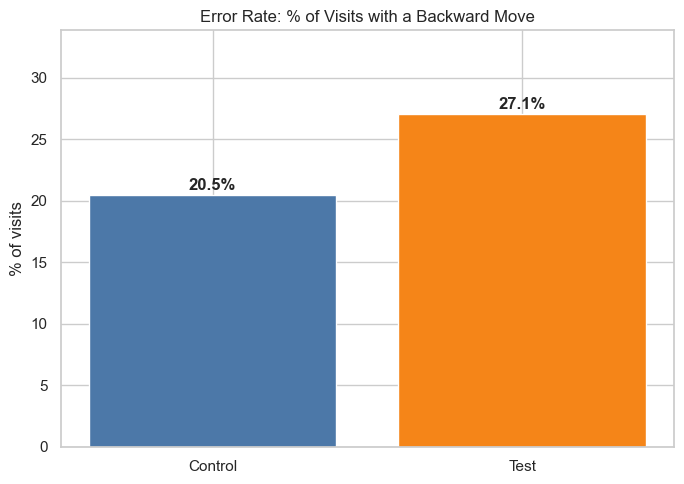

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
vals = (error_summary["pct_visits_with_error"] * 100).reindex(["Control", "Test"])
bars = ax.bar(vals.index, vals.values, color=[GROUP_COLORS[g] for g in vals.index])
ax.set_title("Error Rate: % of Visits with a Backward Move")
ax.set_ylabel("% of visits")
ax.set_ylim(0, max(vals.values) * 1.25)
for b, v in zip(bars, vals.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.4, f"{v:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Additional KPIs

To round out the picture beyond the three required KPIs:

- **Funnel drop-off** - share of visits that reach at least each step
- **Bounce rate** - visits that never progress past `start`
- **Step repeats** - visits that revisit the same step (hesitation / re-loading)
- **Time-to-complete** - for completed journeys, total minutes from start to confirm

In [12]:
# --- Funnel: share of visits reaching at least each step ---
funnel = {}
for name, idx in STEP_ORDER.items():
    funnel[name] = visit.groupby("Variation")["max_step"].apply(lambda s: (s >= idx).mean())
funnel = pd.DataFrame(funnel).T.reindex(STEP_NAMES)[["Control", "Test"]]
print("Share of visits reaching at least each step:")
funnel

Share of visits reaching at least each step:


Variation,Control,Test
start,1.0000,1.0000
step_1,0.7647,0.8630
step_2,0.6562,0.7577
step_3,0.5928,0.6885
confirm,0.4980,0.5848


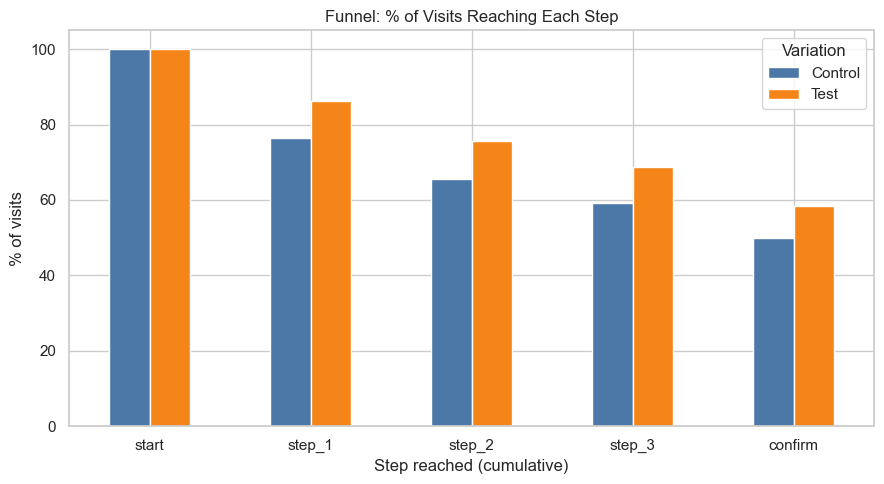

In [13]:
ax = (funnel * 100).plot(kind="bar", figsize=(9, 5),
                         color=[GROUP_COLORS["Control"], GROUP_COLORS["Test"]])
ax.set_title("Funnel: % of Visits Reaching Each Step")
ax.set_ylabel("% of visits")
ax.set_xlabel("Step reached (cumulative)")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

In [14]:
# --- Bounce rate: visits that never get past 'start' ---
bounce = visit.assign(bounce=visit["max_step"] == 0).groupby("Variation")["bounce"].mean()

# --- Step repeats: visit revisits the same step at least once ---
step_counts = df.groupby(["visit_id", "process_step"]).size()
visit_has_repeat = (step_counts > 1).groupby(level=0).any()
repeat_rate = (
    visit_has_repeat.to_frame("has_repeat")
    .join(visit[["Variation"]])
    .groupby("Variation")["has_repeat"].mean()
)

# --- Time-to-complete (completed visits only), in minutes ---
completed = visit[visit["reached_confirm"]].copy()
completed["total_min"] = (completed["end_time"] - completed["start_time"]).dt.total_seconds() / 60
ttc = completed.groupby("Variation")["total_min"].agg(median_min="median", mean_min="mean")

extra = pd.DataFrame({
    "bounce_rate":        bounce,
    "step_repeat_rate":   repeat_rate,
    "ttc_median_min":     ttc["median_min"],
    "ttc_mean_min":       ttc["mean_min"],
}).reindex(["Control", "Test"])
extra

,bounce_rate,step_repeat_rate,ttc_median_min,ttc_mean_min
Variation,,,,
Control,0.2353,0.3748,4.4833,6.6305
Test,0.1370,0.4501,3.5833,6.0666


## 6. KPI Summary and Redesign Verdict

All KPIs consolidated into one Test-vs-Control comparison with the lift
(Test - Control). For completion, funnel and time-to-complete, higher/faster is
better; for error, bounce and step-repeat rates, lower is better.

In [15]:
def g(series, grp):
    return series.loc[grp]

summary = pd.DataFrame({
    "Control": {
        "Completion rate (visit)":       g(completion["completion_rate"], "Control"),
        "Completion rate (client)":      g(client_completion["completion_rate"], "Control"),
        "Error rate (% visits)":         g(error_summary["pct_visits_with_error"], "Control"),
        "Backward moves / visit":        g(error_summary["backward_per_visit"], "Control"),
        "Bounce rate":                   g(bounce, "Control"),
        "Step-repeat rate":              g(repeat_rate, "Control"),
        "Time-to-complete (median min)": g(ttc["median_min"], "Control"),
    },
    "Test": {
        "Completion rate (visit)":       g(completion["completion_rate"], "Test"),
        "Completion rate (client)":      g(client_completion["completion_rate"], "Test"),
        "Error rate (% visits)":         g(error_summary["pct_visits_with_error"], "Test"),
        "Backward moves / visit":        g(error_summary["backward_per_visit"], "Test"),
        "Bounce rate":                   g(bounce, "Test"),
        "Step-repeat rate":              g(repeat_rate, "Test"),
        "Time-to-complete (median min)": g(ttc["median_min"], "Test"),
    },
})
summary["Lift (Test - Control)"] = summary["Test"] - summary["Control"]
summary

,Control,Test,Lift (Test - Control)
Completion rate (visit),0.4980,0.5848,0.0868
Completion rate (client),0.6546,0.6917,0.0371
Error rate (% visits),0.2047,0.2708,0.0661
Backward moves / visit,0.3015,0.4410,0.1395
Bounce rate,0.2353,0.1370,-0.0983
Step-repeat rate,0.3748,0.4501,0.0753
Time-to-complete (median min),4.4833,3.5833,-0.9000


In [16]:
# Data-driven narrative so the conclusion always matches the numbers
ct = completion.loc["Test", "completion_rate"]
cc = completion.loc["Control", "completion_rate"]
rel = (ct - cc) / cc * 100
et = error_summary.loc["Test", "pct_visits_with_error"]
ec = error_summary.loc["Control", "pct_visits_with_error"]

print("REDESIGN SCORECARD (Test vs Control)")
print("-" * 48)
print(f"Completion rate : {ct:.1%} vs {cc:.1%}  "
      f"({(ct-cc)*100:+.1f} pp, {rel:+.1f}% relative)")
print(f"Error rate      : {et:.1%} vs {ec:.1%}  ({(et-ec)*100:+.1f} pp)")
print(f"Bounce rate     : {bounce['Test']:.1%} vs {bounce['Control']:.1%}")
print(f"Time-to-complete: {ttc.loc['Test','median_min']:.1f} vs "
      f"{ttc.loc['Control','median_min']:.1f} min (median)")
print("-" * 48)
print("Note: statistical significance of these differences is tested in Phase 3.")

REDESIGN SCORECARD (Test vs Control)
------------------------------------------------
Completion rate : 58.5% vs 49.8%  (+8.7 pp, +17.4% relative)
Error rate      : 27.1% vs 20.5%  (+6.6 pp)
Bounce rate     : 13.7% vs 23.5%
Time-to-complete: 3.6 vs 4.5 min (median)
------------------------------------------------
Note: statistical significance of these differences is tested in Phase 3.


### Interpretation

Read the scorecard above together with the summary table:

- **Completion rate** is the primary success measure. A positive lift means the
  redesign moved more journeys to `confirm`.
- **Error rate / backward moves** indicate confusion. The redesign should reduce
  these if the new UI is clearer.
- **Time per step / time-to-complete** show efficiency - but interpret with care:
  more time on the new UI is not automatically bad if completion also rises.
- **Bounce and step-repeat rates** capture early abandonment and hesitation.

> **Important:** these are descriptive differences. Whether the completion-rate
> lift is **statistically significant** (and whether it clears Vanguard's
> cost-effectiveness threshold) is answered in **Phase 3 - Hypothesis Testing**.